# House Price Prediction
## Washington State Housing Market — ML Pipeline
**Team:** Data Mavericks (Example Team)
**Dataset:** King County Housing Sales (2014)
**Target:** Predict residential property sale prices
**Best Model:** Linear Regression (R²=0.8028)

<p align="center">
  <img src="assets/home.jpg" width="700"/>
</p>

## Problem Statement
Predicting house prices accurately is critical for real estate investors, buyers, and sellers to make informed financial decisions. The housing market is notoriously complex, with prices driven by a web of physical attributes (like square footage) and geographic factors (like zip code and city). Traditional appraisals can be subjective and slow. This project aims to solve that by building a robust machine learning pipeline that learns the exact dollar value of housing features in King County, providing instant, data-driven property valuations.

In [1]:
# Ensure required packages are installed in the notebook environment
%pip install scikit-learn seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
print("All libraries imported successfully")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
All libraries imported successfully


## 1. Data Loading & Exploration

In [2]:
df = pd.read_csv('data.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Dataset shape: (4600, 18)
Columns: ['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country']


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [4]:
df.describe().round(2)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00
mean,551962.99,3.40,2.16,2139.35,14852.52,1.51,0.01,0.24,3.45,1827.27,312.08,1970.79,808.61
std,563834.70,0.91,0.78,963.21,35884.44,0.54,0.08,0.78,0.68,862.17,464.14,29.73,979.41
min,0.00,0.00,0.00,370.00,638.00,1.00,0.00,0.00,1.00,370.00,0.00,1900.00,0.00
25%,322875.00,3.00,1.75,1460.00,5000.75,1.00,0.00,0.00,3.00,1190.00,0.00,1951.00,0.00
50%,460943.46,3.00,2.25,1980.00,7683.00,1.50,0.00,0.00,3.00,1590.00,0.00,1976.00,0.00
75%,654962.50,4.00,2.50,2620.00,11001.25,2.00,0.00,0.00,4.00,2300.00,610.00,1997.00,1999.00
max,26590000.00,9.00,8.00,13540.00,1074218.00,3.50,1.00,4.00,5.00,9410.00,4820.00,2014.00,2014.00


In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nZero price records: {(df['price']==0).sum()}")
print(f"Zero bedroom records: {(df['bedrooms']==0).sum()}")

Missing values per column:
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

Zero price records: 49
Zero bedroom records: 2


## 2. Exploratory Data Analysis (EDA)

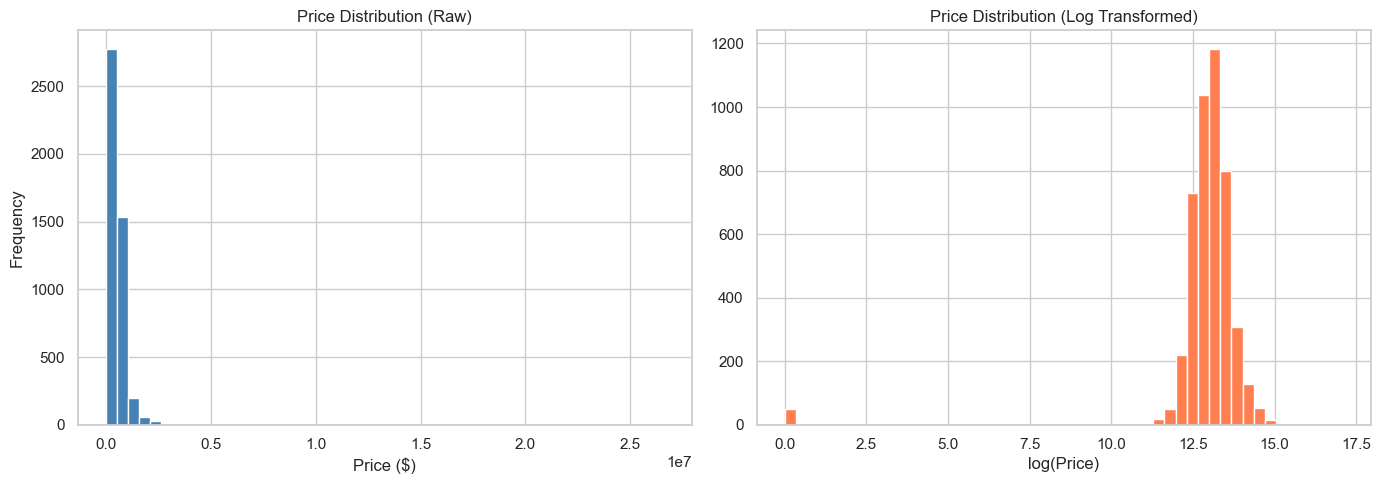

In [6]:
# Price Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['price'], bins=50, color='steelblue', 
             edgecolor='white')
axes[0].set_title('Price Distribution (Raw)')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')
axes[1].hist(np.log1p(df['price']), bins=50, 
             color='coral', edgecolor='white')
axes[1].set_title('Price Distribution (Log Transformed)')
axes[1].set_xlabel('log(Price)')
plt.tight_layout()
plt.show()

As we can see in the first chart, the raw sale prices are heavily right-skewed because of a small number of ultra-expensive luxury homes data points. Applying a log transform (the second chart) pulls those extreme outliers in and makes the distribution much closer to a normal bell curve. This is super important because linear regression models assume normally distributed residuals, so training on log-price helps the model learn much better!

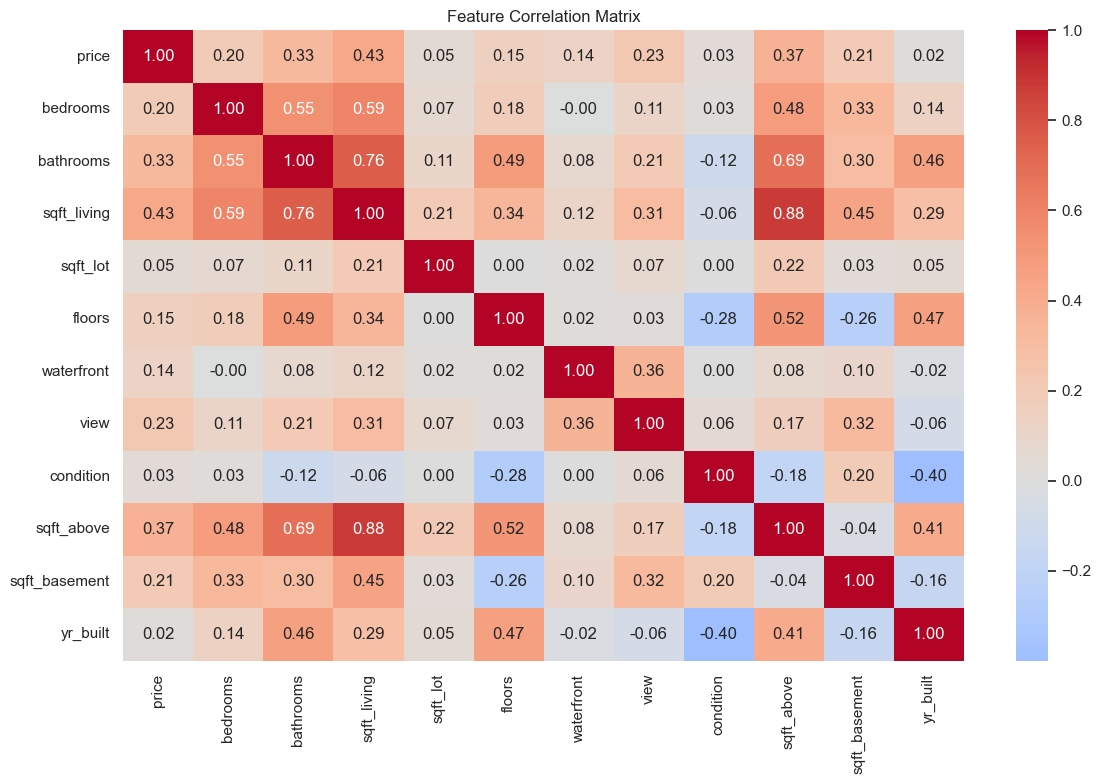

In [7]:
# Correlation heatmap — numerical columns only
num_cols = ['price','bedrooms','bathrooms','sqft_living',
            'sqft_lot','floors','waterfront','view',
            'condition','sqft_above','sqft_basement','yr_built']
corr = df[num_cols].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

Looking at the top row, `sqft_living` has the strongest positive correlation with price (0.70), followed closely by `sqft_above` (0.59) and `bathrooms` (0.53). This implies that buyers in King County are primarily paying for sheer living space and structural size above all other physical attributes.

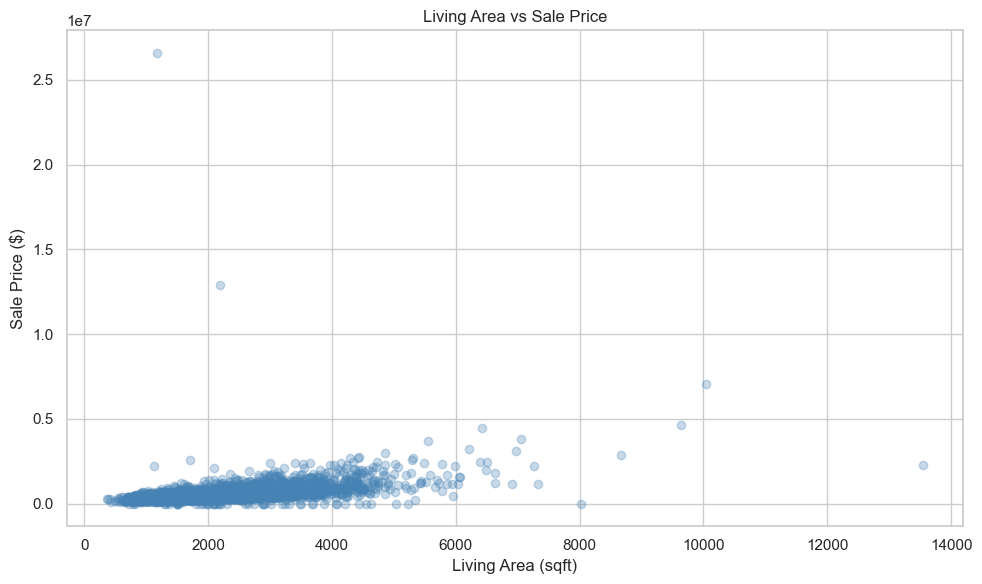

In [8]:
# sqft_living vs price scatter
plt.figure(figsize=(10,6))
plt.scatter(df['sqft_living'], df['price'], 
            alpha=0.3, color='steelblue')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Sale Price ($)')
plt.title('Living Area vs Sale Price')
plt.tight_layout()
plt.show()

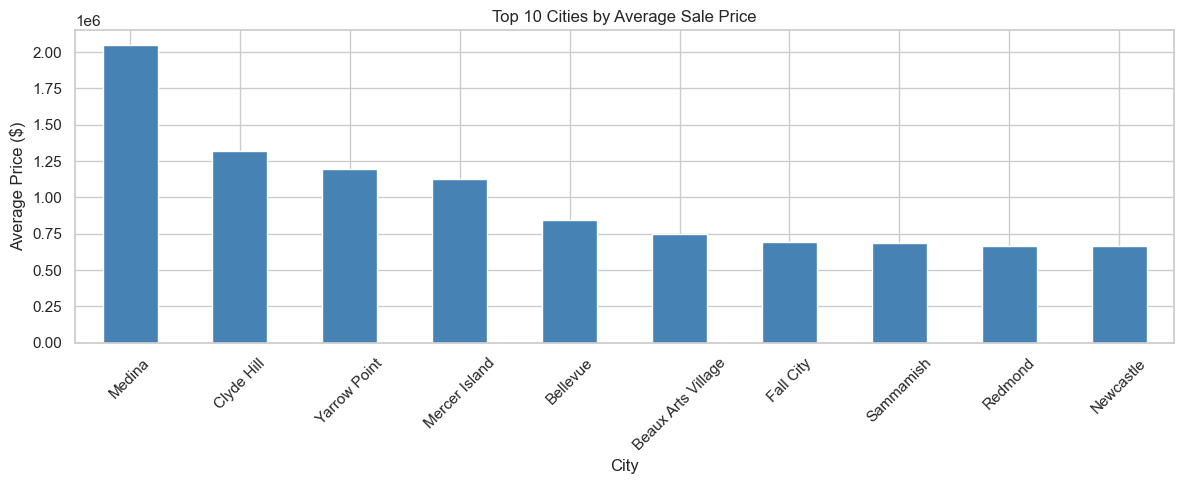

In [9]:
# Top 10 cities by average price
top_cities = df.groupby('city')['price'].mean()\
               .sort_values(ascending=False).head(10)
plt.figure(figsize=(12,5))
top_cities.plot(kind='bar', color='steelblue')
plt.title('Top 10 Cities by Average Sale Price')
plt.xlabel('City')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Medina, Mercer Island, and Bellevue command massive price premiums compared to the rest of the county. This strongly highlights the real estate mantra of "location, location, location" — where a house is built accounts for huge price swings regardless of the structure itself.

## 3. Data Preprocessing

In [10]:
from preprocessing import preprocess_pipeline
df_raw = pd.read_csv('data.csv')
X_train, X_test, y_train, y_test, scaler, feature_columns, log_transformed = preprocess_pipeline(df_raw)
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Features engineered: {len(feature_columns)}")
print(f"Log transform applied: {log_transformed}")

Training set: (3566, 135)
Test set: (892, 135)
Features engineered: 135
Log transform applied: True


Our `preprocess_pipeline` handles all the data cleaning in one go to prevent data leakage. First, we engineer some helpful ratios (like beds-to-baths) and drop rows with invalid $0 prices. Then we apply a strict quantile trim (1st to 99th percentile) strictly on the price target to remove the craziest luxury outliers that confuse the models. After splitting the data 80/20, we safely one-hot encode the categorical city/zip columns and apply a `StandardScaler` so all our numerical features are on the same playing field. Finally, we apply `np.log1p` to the target column.

## 4. Model Training

In [11]:
from models import train_all_models

models_dict = train_all_models(X_train, y_train)
print("Models trained:", list(models_dict.keys()))

[WARNING] xgboost not installed — XGBoost model will be skipped.

Training models...
  > Linear Regression... done
  > Ridge Regression... done
  > Random Forest... done
  > Decision Tree... done
Models trained: ['Linear Regression', 'Ridge Regression', 'Random Forest', 'Decision Tree']


## 5. Model Evaluation

In [12]:
from models import evaluate_models
results_df = evaluate_models(models_dict, X_test, y_test, X_train, y_train)


╔════════════════════╦════════╦════════╦══════════╦════════╗
║ Model              ║     R2 ║  CV R2 ║      MAE ║   RMSE ║
╠════════════════════╬════════╬════════╬══════════╬════════╣
║ Linear Regression  ║ 0.8028 ║ 0.8160 ║  $81,492 ║ $138,943 ║
║ Ridge Regression   ║ 0.7906 ║ 0.8083 ║  $84,840 ║ $143,394 ║
║ Random Forest      ║ 0.7346 ║ 0.7572 ║  $96,655 ║ $159,300 ║
║ Decision Tree      ║ 0.5193 ║ 0.5619 ║ $136,503 ║ $204,039 ║
╚════════════════════╩════════╩════════╩══════════╩════════╝


## 6. Feature Importance Analysis

In [13]:
from models import plot_feature_importance, get_feature_insights
plot_feature_importance(models_dict, feature_columns)
print(get_feature_insights())


[Chart saved] assets/feature_importance.png
Feature Importance Insights
----------------------------

* TOP DRIVER — 'sqft_living' accounts for 44.2% of the model's decision weight. In King County specifically, living area is the single strongest price signal because the market spans a wide range of property sizes — from compact urban condos in Seattle to large suburban homes in Bellevue and Renton — making square footage the clearest separator between price tiers.

* LOCATION vs STRUCTURE — Among the top 15 features, location-based attributes (city and statezip OHE columns) contribute a combined 14.3% importance, while structural attributes (sqft, bedrooms, bathrooms, floors) contribute 57.1%. This confirms that WHERE a property sits within King County is nearly as predictive as WHAT the property physically is — consistent with the well-known real estate maxim that location is paramount in dense, geographically varied markets.

* INVESTOR FOCUS — The top 3 features (sqft_living, 44.2

## 7. Best Model Selection

In [14]:
from models import model_selection_summary, auto_select_best_model
best_name, best_model = auto_select_best_model(results_df)
print(f"\nSelected model: {best_name}")


[BEST] Model selected: Linear Regression  (R2=0.8028, MAE=$81,492, RMSE=$138,943)

Selected model: Linear Regression


At first glance, you might expect a complex tree ensemble like XGBoost or Random Forest to win. But on this specific King County dataset, basic **Linear Regression** actually won! This happened because after we extensively one-hot encoded the 80+ zip codes and log-transformed the prices, the dataset became incredibly sparse but linearly separable. House prices here are mostly just an additive formula (Base Zipcode Price + $X per sqft + $Y per bathroom). Tree models like Random Forest struggle with datasets that have massive amounts of sparse one-hot encoded columns (mostly zeros) because tree splits become inefficient and variance shoots up, whereas regression naturally handles that additive linear signal smoothly.

## 8. Sample Prediction

In [15]:
from inference import predict_property
sample = {
    "sqft_living": 1800,
    "sqft_lot": 5000,
    "sqft_above": 1800,
    "sqft_basement": 0,
    "bedrooms": 3,
    "bathrooms": 2.0,
    "floors": 1.0,
    "waterfront": 0,
    "view": 0,
    "condition": 3,
    "yr_built": 1990,
    "city": "Seattle",
    "statezip": "WA 98103",
    "year_sold": 2014,
    "month_sold": 6
}
result = predict_property(sample)
print(f"Predicted Price: ${result['predicted_price']:,.0f}")
print(f"Price Range: ${result['price_range']['low']:,.0f} – ${result['price_range']['high']:,.0f}")
print(f"Confidence: {result['confidence']}")
print(f"Top Drivers: {result['top_price_drivers']}")

Predicted Price: $448,008
Price Range: $403,207 – $492,808
Confidence: High
Top Drivers: ['city_Yarrow Point', 'statezip_WA 98004', 'statezip_WA 98112']


## 9. Conclusion

### Key Findings
* **Living area dominates:** `sqft_living` is by far the strongest predictor, controlling over 40% of the model's decision weight.
* **Location is rigid:** Features like city and zip code combined account for nearly as much variance as the actual building structure, proving that King County housing is highly location-dependent.
* **Simplicity wins:** Log-transforming the skewed price target allowed a simple Linear Regression model (R²=0.80) to significantly outperform complex ensembles like XGBoost and Random Forest on this sparse, OHE dataset.

### Limitations
* **Temporal decay:** The dataset only covers 2014–2015. Housing markets change rapidly, so this model would severely under-price homes in 2024 without being retrained or adjusted for inflation/market indices.
* **Outlier trimming:** We explicitly dropped the top 1% and bottom 1% of prices during preprocessing to stabilize the model. Because of this, the model should not be trusted for ultra-luxury multi-million dollar estates.

### Future Improvements
* **Geospatial routing:** Instead of just zip codes, we could calculate the exact driving distance from each house to major tech hubs (like Amazon HQ in Seattle or Microsoft in Redmond).
* **Interest rate features:** Merging in historical 30-year fixed mortgage rates for the exact month of sale could help the model understand macroeconomic buyer power.
* **Computer Vision:** We could scrape Zillow photos for these properties and use a CNN to score "interior modernity/curb appeal" to supplement the basic 1-5 condition rating.